<a href="https://colab.research.google.com/github/annacrislj-coder/telecom-analysis/blob/main/telecom_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
print (plans.head())

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [ ]:
# mostrar las primeras 5 filas de users
print (users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [ ]:
# mostrar las primeras 5 filas de usage
print (usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
print ("plans", plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
plans None


In [ ]:
# inspección de users con .info()
print ("users", users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
users None


In [ ]:
# inspección de usage con .info()
print ("usage", usage.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
usage None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("users", users.isna().sum()) # Cantidad de valores nulos)
print("users", users.isna().mean()) # Proporción de valores nulos)

users user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
users user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print ("usage", usage.isna().sum())
print ("usage", usage.isna().mean())

usage id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
usage id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  Encontamos valores nulos en el dataset de users en la columnas de city con 12% y churn day con 89%. En usage tenemos valores nulos en usage, date con 1%, duration con 56%, lenght con 45%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Consuderando los % de nulos en los datasets imputaremos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print (users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` observamos que el promedio es mayor a la desviación estandar. Indica disperción de datos.
- La columna `age` observamos que el minimo es negativo, lo cual es errorneo.

In [ ]:
# explorar columnas numéricas de usage
print (usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` hay variabilidad entre el promedio y la desviación estandar indica disperción de datos.
- Las columnas "duración" y "lenght" tiene variabilidad deribada de los nulos que vimos anteriormente. A su vez vemos que hay poca disperción de datos pero poca diferencia entre promedio y la desviación estandar.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print (users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta 7 valores únicos, 7 ciudades diferentes, sin embargo en la columna de city tenemos valores nulos.
- La columna `plan` presenta solo dos valores únicos que sabiamos.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tenemos solo 2 valores únicos y no existen valores nulos.


---
✍️ **Comentario**: En este data set vemos que hay sentinels en la edad, ciudad pues hay valores nulos los cuales debemos de analizar y corregir en su defecto.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en City y Age
- ¿Qué acción tomarías?  Para corregir el los valores nulos en las columnas de City y Age y así analizar el dataset.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"]) # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"]) # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
print (users ['reg_date'])
print (users ['reg_date'].describe())


0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]
count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object


En `reg_date`, tenemos información de los años 2022 hasta 2026. Situación extraña ya que aún no transcurre el 2026.  

In [ ]:
# Revisar los años presentes en `date` de usage
print (usage['date'])
print (usage ['date'].describe())


0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]
count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object


En `date`, se tienen registros del 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? En nuestro data ser de users existen registro del 2026 año aún no transcurrido. (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas? Fechas futura es mejor eliminarlas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
sentinels = [-999]
age_mediana = (users["age"].median())
users['age'] = (users["age"].replace(sentinels, age_mediana))

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
sentinels = ["?"]
users["city"] = (users["city"].replace(sentinels, pd.NA))

# Verificar cambios
users["city"].describe

<bound method NDFrame.describe of 0       Medellín
1           <NA>
2           CDMX
3         Bogotá
4            GDL
          ...   
3995    Medellín
3996    Medellín
3997      Bogotá
3998      Bogotá
3999      Bogotá
Name: city, Length: 4000, dtype: object>

In [ ]:
# Marcar fechas futuras como NA para reg_date
sentinels = [2022, 2026]
year_clean =(users['reg_date'].replace(sentinels, pd.NA))
# Verificar cambios
year_clean.describe

<bound method NDFrame.describe of 0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x : x .isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x : x .isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration`: 22076 lo que se traduce a MAR y `length`: 17896 siendo MAR, por lo cual esos valores conyinuaran siendo nulos pues no afecta nuestro dataset para su analisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["is_duration"] = (usage["duration"]) #conocer el total de minutos por llamada

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes = ('is_text', 'sum'), cant_llamadas =("is_call", 'sum') , cant_minutos=("is_duration", 'sum')).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns= {
    "is_text" : "cant_mensajes",
    "is_cant" : "cant_llamadas",
    "is_duration" : "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how='inner')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile = user_profile[user_profile["reg_date"].dt.year == 2024] # Filtrando el dataset para trabajar solo con 2024
columnas_numericas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,13332.699248,48.414286,5.500000,4.557143,24.126669
std,384.969999,17.963443,2.382293,2.140329,19.458620
min,12666.000000,18.000000,0.000000,0.000000,0.000000
25%,12999.250000,33.000000,4.000000,3.000000,11.332500
50%,13333.500000,48.000000,5.000000,4.000000,20.325000
75%,13665.750000,64.000000,7.000000,6.000000,32.542500
max,13999.000000,79.000000,16.000000,13.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.656391
Premium    0.343609
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

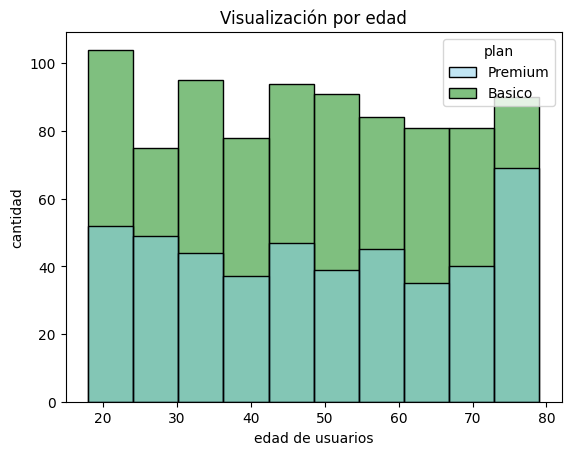

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x="age", hue='plan', bins=10, palette=["skyblue", "green"], kde= False)
plt.xlabel('edad de usuarios')
plt.ylabel('cantidad')
plt.title ("Visualización por edad")
plt.show()

💡Insights:
- Distribución del plan Premium es mayor en los usuarios adultos mayos (75-80 años), mientras que los usuarios menores de 25 años preponderan en los planes básicos. Los planes básicos son los más demandados por nuestros clientes.

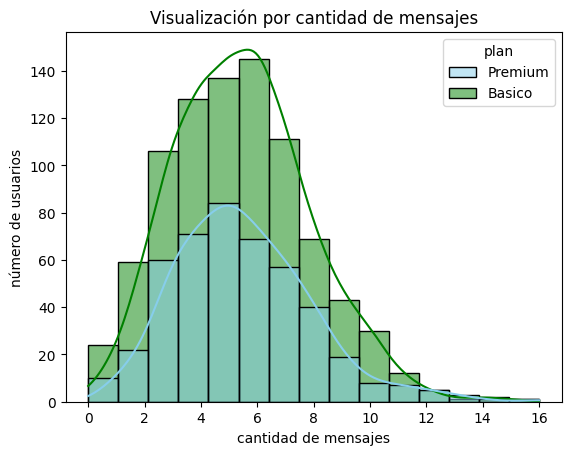

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x="cant_mensajes", hue='plan', bins=15, palette=["skyblue", "green"], kde= True)
plt.xlabel('cantidad de mensajes')
plt.ylabel('número de usuarios')
plt.title ("Visualización por cantidad de mensajes")
plt.show()

💡Insights:
- Observamos que niestro grafico se encuentra sesgado a la derecha al tener una cola hacia la derecha y la mayoria de los usuarios se cocentra en el lado izquierdo. para el plan premium la mayor cantidad de mensajes es de 5 y en el básico es de 7 con 140 usuarios.

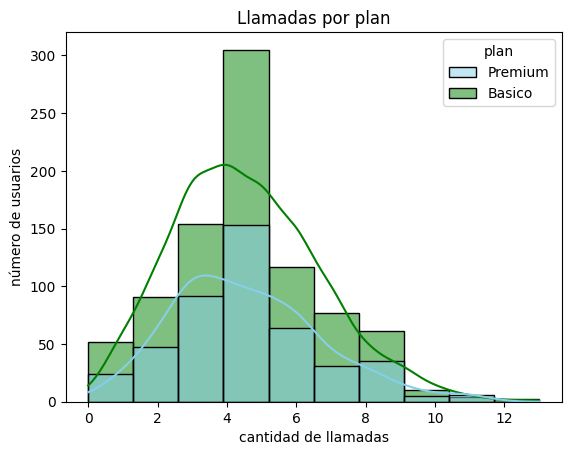

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x="cant_llamadas", hue='plan', bins=10, palette=["skyblue", "green"], kde= True)
plt.xlabel('cantidad de llamadas')
plt.ylabel('número de usuarios')
plt.title ("Llamadas por plan")
plt.show()

💡Insights:
- Distribución de llamadas es de 5 para ambos planes. observamos que el gráfico se encuentra sesgado a la derecha. Los usuarios del plan básico realizan en su mayoria 5 llamadas.

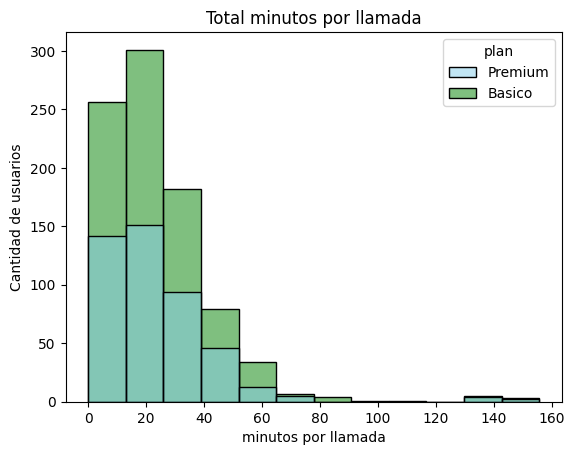

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x="cant_minutos", hue='plan', bins=12, palette=["skyblue", "green"], kde= False)
plt.xlabel('minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.title ("Total minutos por llamada")
plt.show()

💡Insights:
- Los usuarios del plan básico tienden a permanecer hablando de 20-30 minutos contra los usuarios de Premium que demoran de alrededor de 15 minutos. observamos que nuesto grafico tiene un sesgo a la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

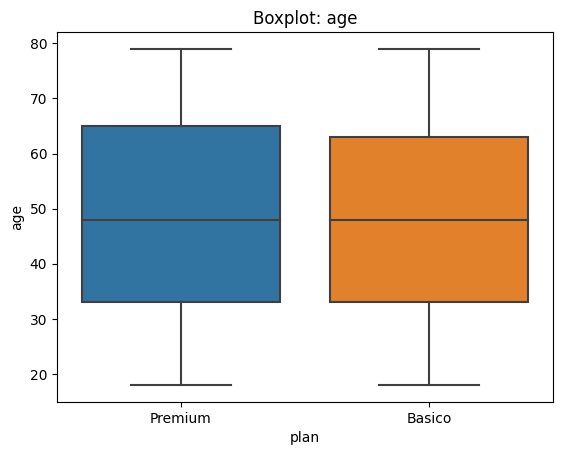

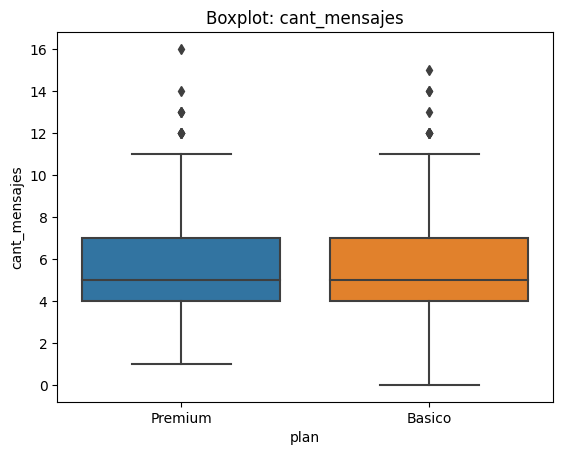

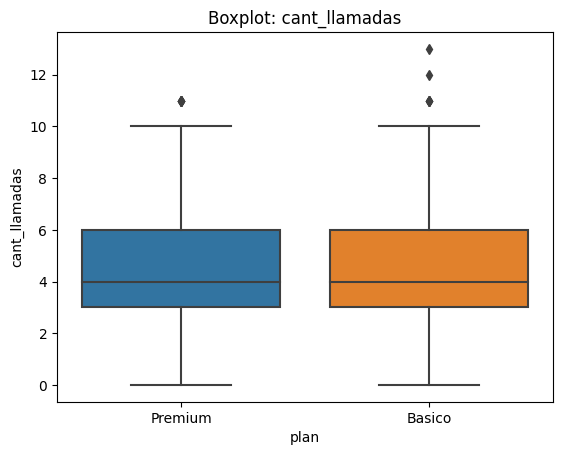

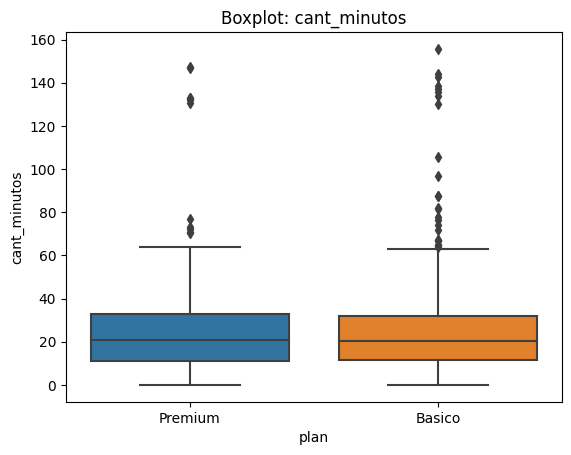

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos']

for col in columnas_numericas:
        sns.boxplot (data= user_profile, x="plan", y= col)
        plt.title(f'Boxplot: {col}')
        plt. show()


💡Insights:
- Age: no presenta outliers y se centra en su mayoria las edades de clientes dentro de nuestro rango intercuartil
- cant_mensajes: hay presencia de outliers,
- cant_llamadas: precencia de outliers en ambos planes.
- cant_minutos_llamada: gran número de outliers sobre todo en el plan básico

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos']
for col in columnas_limites:
     Q1 = user_profile[col].quantile(0.25)
     Q3 = user_profile[col].quantile(0.75)
     IQR = Q3 - Q1
     limite_superior = Q3 + 1.5 * IQR

print ('Primer cuartil :', Q1)
print ('Primer cuartil :', Q3)
print ('IQR:', IQR)
print ("\nRegistros arriba del límite superior")
print(user_profile[user_profile[col] > limite_superior][col])


Primer cuartil : 11.3325
Primer cuartil : 32.5425
IQR: 21.209999999999997

Registros arriba del límite superior
2667     87.56
2676     73.00
2710    132.92
2735     87.38
2785    137.05
2920     66.52
2935    130.84
2960    146.92
3044     96.88
3125     67.32
3183     76.69
3186    138.41
3241     67.11
3264    147.53
3296     70.21
3297    130.23
3324    143.97
3339     74.05
3349     82.18
3384     64.67
3386     76.65
3398     70.80
3492    131.88
3514     77.74
3611    105.54
3641     81.59
3663     72.16
3733     64.77
3849    142.84
3919    132.72
3926    135.96
3944    133.97
3952    155.69
3966     71.76
Name: cant_minutos, dtype: float64


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos
count,1330.000000,1330.000000,1330.000000
mean,5.500000,4.557143,24.126669
std,2.382293,2.140329,19.458620
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.332500
50%,5.000000,4.000000,20.325000
75%,7.000000,6.000000,32.542500
max,16.000000,13.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantendremos el outlier pues consideramos que se trata de un comportamiento real extraordinario.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
]
valores = ['bajo uso', 'uso medio']
user_profile['grupo_uso']= np.select(condiciones, valores, default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos,grupo_uso
2665,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00.000000000,Premium,NaN,13,3,11.50,Alto uso
2666,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,3,7,33.27,uso medio
2667,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240,Basico,NaN,5,7,87.56,uso medio
2668,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,4,5,27.62,uso medio
2669,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,9,4,31.90,uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones = [
    (user_profile["age"] < 30),
    (user_profile["age"] < 60)
]
valores = ['Joven', 'Adulto']
user_profile['grupo_edad']= np.select(condiciones, valores, default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos,grupo_uso,grupo_edad
2665,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00.000000000,Premium,NaN,13,3,11.50,Alto uso,Joven
2666,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,3,7,33.27,uso medio,Adulto Mayor
2667,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240,Basico,NaN,5,7,87.56,uso medio,Joven
2668,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,4,5,27.62,uso medio,Adulto
2669,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,9,4,31.90,uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

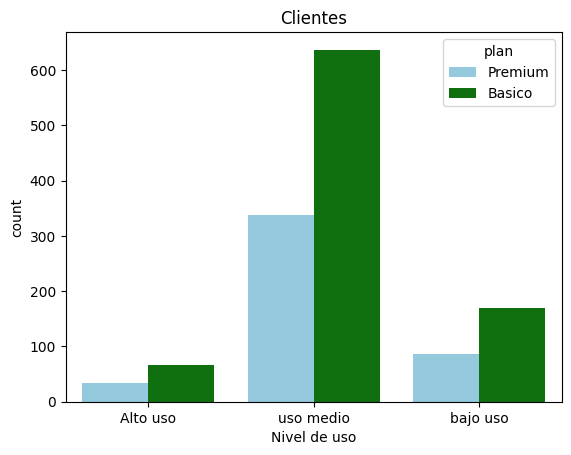

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, x='grupo_uso', hue='plan', palette=["skyblue", "green"])
plt.xlabel('Nivel de uso')
plt.title('Clientes')
plt.show()

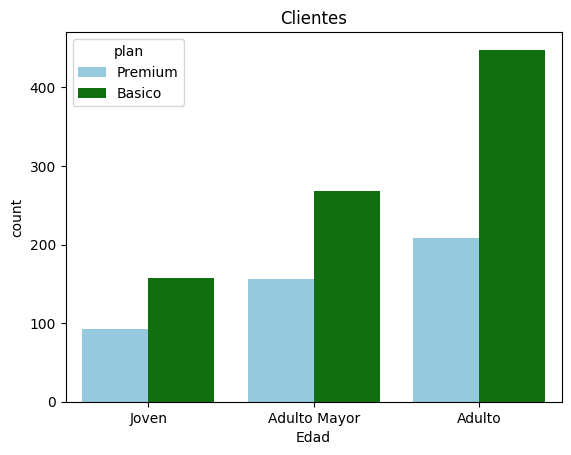

In [ ]:
# Visualización de los segmentos por edad
sns.countplot (data= user_profile, x='grupo_edad', hue='plan', palette=["skyblue", "green"])
plt.xlabel('Edad')
plt.title('Clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- El dataset venia con valores nulos y sentinels a la hora revisar el DF.
- Se realizo la respectiba limpieza de DF, optamos por imputar los valores para su analisis.
- Se analizo solo a los lcientes del 2024.


🔍 **Segmentos por Edad**
- Encontramos que la mayoria de nuestro clientes con Plan Básico son en el 2024 fueron adultos.
- El resto tiene el plan Premium quienes en su mayoria son adultos con 200.


📊 **Segmentos por Nivel de Uso**
- nuestros clientes en su mayoría usa sus planes en llamadas y mensajes un promedio menor a 10 veses al mes.


➡️ Esto sugiere que el core de negoción esta enfocado a la población adulta y nuestro producto más vendido es el plan tarifa básica.


💡 **Recomendaciones**
- promover o adecuar un plan premium para nuestros clientes adultos y así fidelizarlos con alguna oferta para realizar el cambio.
- buscar vender paquetes básicos a empresas para que sus empleados usen nuestros servicios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`